<a href="https://colab.research.google.com/github/bereketsimma/Beautysalon-booking/blob/main/wordembading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install gensim
!pip install nltk
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn


import os
import random

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from gensim.models.keyedvectors import KeyedVectors  # handle word vectors separately

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import reuters
nltk.download('reuters')
nltk.download('punkt_tab') # Download missing punkt_tab resource

[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import gensim.downloader as api

# Load Text8 dataset (already tokenized into lists of words)
dataset = api.load("text8")

# Convert generator to list of sentences
corpus_text8 = list(dataset)


# Print a few sentences
for i in range(3):
    print(f"Sentence {i+1}:", corpus_text8[i][:20])  # first 20 tokens
def preprocess(sent):
    return [w.lower() for w in sent if w.isalpha()]

corpus_text8_clean = [preprocess(s) for s in corpus_text8]
print("Clean sentences:", len(corpus_text8_clean))
print("Clean vocab size:", len(set([w for s in corpus_text8_clean for w in s])))
print("Clean example sentence:", corpus_text8_clean[0][:20])

Sentence 1: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']
Sentence 2: ['reciprocity', 'qualitative', 'impairments', 'in', 'communication', 'as', 'manifested', 'by', 'at', 'least', 'one', 'of', 'the', 'following', 'delay', 'in', 'or', 'total', 'lack', 'of']
Sentence 3: ['with', 'the', 'aegis', 'of', 'zeus', 'when', 'he', 'goes', 'to', 'the', 'battlefield', 'the', 'entire', 'trojan', 'army', 'flees', 'behind', 'the', 'walls', 'of']
Clean sentences: 1701
Clean vocab size: 253854
Clean example sentence: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


In [8]:


# Cell 4: Train Word2Vec (CBOW)

embedding_dim = 100
window_size = 5       # context window
min_count = 1         # ignore rare words
sg = 0
workers = 4
epochs = 5

model_cbow = Word2Vec(
    sentences=corpus_text8_clean,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True
)
model_cbow.save("word2vec_cbow_demo.model")




[('son', 0.6447196006774902)]
[('berlin', 0.8212804198265076)]
[('smaller', 0.7552223801612854)]


In [5]:

# Cell 4: Train Word2Vec
embedding_dim = 100
window_size = 5
min_count = 5
sg = 1
workers = 4
epochs = 5

model_skip = Word2Vec(
    sentences=corpus_text8_clean,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True

)


[('queen', 0.6547346711158752)]
[('berlin', 0.8332909941673279)]
[('larger', 0.7726268768310547)]


In [9]:
try:
    print("Skip-gram loss:", model_skip.get_latest_training_loss())
except NameError:
    print("Error: 'model_skip' is not defined. Please ensure the Word2Vec Skip-gram model cell (TREZhtbuFGMP) has been executed.")

print("CBOW loss:", model_cbow.get_latest_training_loss())

Skip-gram loss: 68213056.0
CBOW loss: 23315686.0


In [15]:
# Cell 5: Similarity examples
def show_similar(model , word, topn=10):
    if word in model.wv:
        print(f"Top {topn} similar to '{word}':")
        for w, score in model.wv.most_similar(word, topn=topn):
            print(f"  {w:15s}  {score:.4f}")
    else:
        print(f"'{word}' not in vocabulary (min_count may have filtered it).")
words = ["king", "paris", "woman", "small", "man"]
for w in words:
    if w in model_cbow.wv:
        print("\nWord:", w,"with cbow")
        print(model_cbow.wv.most_similar(w, topn=5))
        print("\nWord:", w ,"with skip_gram")
        print(model_skip.wv.most_similar(w, topn=5))

print(model_cbow.wv.most_similar(positive=["king","woman"], negative=["man"], topn=1))

print(model_cbow.wv.most_similar(positive=["paris","germany"], negative=["france"], topn=1))

print(model_cbow.wv.most_similar(positive=["small","bigger"], negative=["big"], topn=1))




model_skip.save("word2vec_cbow_demo.model")
print(model_skip.wv.most_similar(positive=["king","woman"], negative=["man"], topn=1))

print(model_skip.wv.most_similar(positive=["paris","germany"], negative=["france"], topn=1))

print(model_skip.wv.most_similar(positive=["small","bigger"], negative=["big"], topn=1))




Word: king with cbow
[('prince', 0.7542864084243774), ('queen', 0.7161009311676025), ('kings', 0.712821364402771), ('emperor', 0.6994886994361877), ('throne', 0.6993670463562012)]

Word: king with skip_gram
[('prince', 0.7696232795715332), ('haakon', 0.736159086227417), ('valdemar', 0.7305194139480591), ('canute', 0.7230943441390991), ('kings', 0.7209567427635193)]

Word: paris with cbow
[('vienna', 0.7429279088973999), ('munich', 0.7318366169929504), ('venice', 0.7094846367835999), ('leipzig', 0.7007468938827515), ('observateurs', 0.697028398513794)]

Word: paris with skip_gram
[('cimeti', 0.7317917346954346), ('commune', 0.7303849458694458), ('brussels', 0.7295923233032227), ('universelle', 0.7278872728347778), ('rodin', 0.7257040739059448)]

Word: woman with cbow
[('child', 0.7892859578132629), ('girl', 0.7699922919273376), ('man', 0.7413914799690247), ('lady', 0.6830134987831116), ('person', 0.6726176738739014)]

Word: woman with skip_gram
[('prostitute', 0.7281268239021301), ('gi

In [16]:
words_to_plot = [
 # finance / economy
    "market", "money", "bank", "banks", "currency", "dollar", "interest",

    # trade / business
    "trade", "export", "import", "tariffs", "deficit", "surplus", "company",

    # energy / commodities
    "oil", "crude", "gas", "energy", "petroleum", "fuel",

    # institutions / politics
    "government", "central", "federal", "reserve", "minister",

    # geography / macro
    "japan", "usa", "britain", "germany", "europe", "world"]

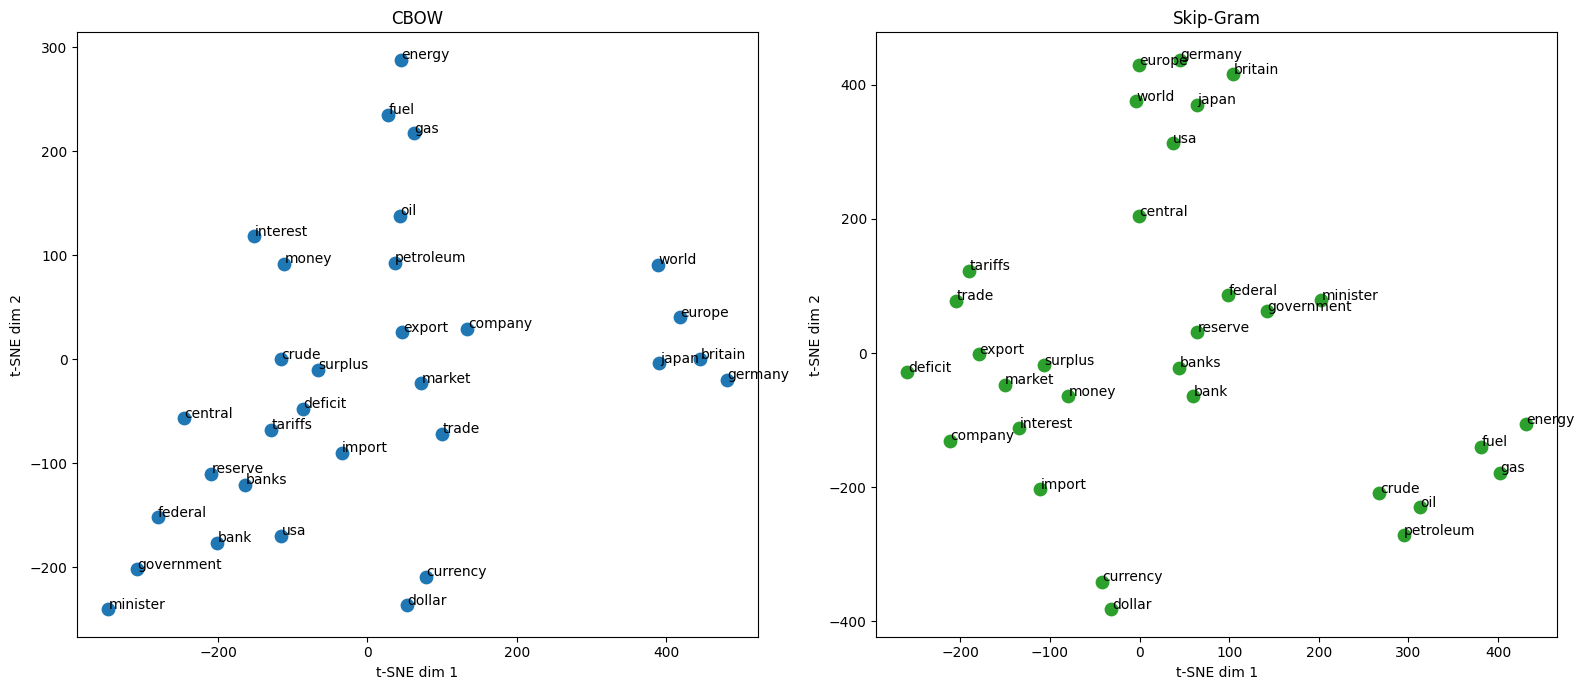

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, title, color in [
    (axes[0], model_cbow, "CBOW", "tab:blue"),
    (axes[1], model_skip, "Skip-Gram", "tab:green")
]:

    words = [w for w in words_to_plot if w in model.wv]
    vectors = np.array([model.wv[w] for w in words])

    pca = PCA(n_components=10, random_state=42)
    vecs_pca = pca.fit_transform(vectors)

    tsne = TSNE(
        n_components=2,
        perplexity=5,
        learning_rate=200,
        max_iter=1000,
        random_state=42
    )

    vecs_2d = tsne.fit_transform(vecs_pca)

    ax.scatter(vecs_2d[:,0], vecs_2d[:,1], s=80, c=color)

    for i, w in enumerate(words):
        ax.text(vecs_2d[i,0]+0.5, vecs_2d[i,1]+0.5, w, fontsize=10)

    ax.set_title(title)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.tight_layout()
plt.show()

In [ ]:
!git clone https://github.com/bereketsimma/wordembading.git


Cloning into 'wordembading'...


In [ ]:
%cd wordembading


/content/wordembading/wordembading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!find /content/drive/MyDrive -name "*.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ViT_CIFAR10_Beginner_Friendly.ipynb
/content/drive/MyDrive/VIT_for_image_classification.ipynb
/content/drive/MyDrive/Colab Notebooks/model explaneblity.ipynb
/content/drive/MyDrive/Colab Notebooks/SHAP_House_Pricing.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/contrastive-learning task.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/neuranlnettest.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/continual-learning.ipynb
/content/drive/MyDrive/Colab Notebooks/qc.ipynb
/content/drive/MyDrive/Colab Notebooks/pca (1).ipynb
/content/drive/MyDrive/Colab Notebooks/pca.ipynb
/conte

In [ ]:
%cd /content/wordembading/wordembading


/content/wordembading/wordembading


In [ ]:
!git remote -v

origin	https://github.com/bereketsimma/wordembading.git (fetch)
origin	https://github.com/bereketsimma/wordembading.git (push)


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/wordembading.ipynb" .
!ls

!git config --global user.name "bereketsimma"
!git config --global user.email "bekisimma@gmail.com"
!git add wordembading.ipynb
!git commit -m "Add Word2Vec Colab notebook"
!git push -u origin main

wordembading.ipynb
[main 1f2507b] Add Word2Vec Colab notebook
 1 file changed, 1 insertion(+), 1 deletion(-)
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!ls
!git status
!git branch --unset-upstream

wordembading.ipynb
On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

nothing to commit, working tree clean
